# Star Wars Original Trilogy Analysis

In [17]:
# pandas library for handling data 
import pandas as pd
# regular expressions library for text pattern matching and cleaning
import re
# for visualizations
import matplotlib.pyplot as plt
# for removing common stopwords 
from nltk.corpus import stopwords
# word tokenizer from NLTK to split text into individual words
from nltk.tokenize import word_tokenize
# the WordNet lemmatizer to reduce words to their base  form
from nltk.stem import WordNetLemmatizer
#to calculate frequency distributions of words
from nltk.probability import FreqDist
# to generate word cloud visualizations
from wordcloud import WordCloud
# Import TF-IDF Vectorizer to calculate term frequency-inverse document frequency for feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
# for performing sentiment analysis on text
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# for natural language processing tasks
import nltk
# Import NumPy for numerical operations and working with arrays
import numpy as np
# Import Image class from PIL (Pillow) for handling image masks for word clouds
from PIL import Image
# path utilities from the os module to handle file system paths
from os import path
# Download NLTK's Punkt tokenizer model 
nltk.download('punkt')
# Download the stopwords list from NLTK
nltk.download('stopwords')
# Download the WordNet lexical database
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rande\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
def parse_dialogues(text):
    # Define a regular expression pattern to extract three groups from each line of text:
    # 1. A numeric ID enclosed in quotes
    # 2. A character's name enclosed in quotes
    # 3. The dialogue spoken by that character, also enclosed in quotes
    pattern = r'"(\d+)"\s+"([^"]+)"\s+"([^"]+)"'
    # It returns a list of tuples with the matched groups.
    matches = re.findall(pattern, text)
    # Convert the list of tuples into a pandas DataFrame with column names:
    # 'id', 'character', and 'dialogue'
    return pd.DataFrame(matches, columns=['id', 'character', 'dialogue'])


In [19]:
# Open the text file for Episode IV in read mode
with open('C:/BI/star_wars_movies_scripts/SW_EpisodeIV.txt', 'r') as f:
    # Read the entire file content into a string variable
    episode_iv_text = f.read()
# Apply the parse_dialogues function to extract dialogue data from Episode IV
episode_iv_df = parse_dialogues(episode_iv_text)
# Add a new column to label this dataset as Episode IV
episode_iv_df['episode'] = 'IV'
with open('C:/BI/star_wars_movies_scripts/SW_EpisodeV.txt', 'r') as f:
    episode_v_text = f.read()
episode_v_df = parse_dialogues(episode_v_text)
episode_v_df['episode'] = 'V'

with open('C:/BI/star_wars_movies_scripts/SW_EpisodeVI.txt', 'r') as f:
    episode_vi_text = f.read()
episode_vi_df = parse_dialogues(episode_vi_text)
episode_vi_df['episode'] = 'VI'

In [20]:
def top_speaker(df):
    # Count how many times each character appears (i.e., speaks) in the DataFrame
    # .value_counts() returns a Series sorted by count in descending order
    # .idxmax() gives the character with the highest count (i.e., most dialogues)
    return df['character'].value_counts().idxmax()
# Call the function for Episode IV and print the character with the most dialogues
print("Top speaker in Episode IV:", top_speaker(episode_iv_df))

# Call the function for Episode V and print the top speaker
print("Top speaker in Episode V:", top_speaker(episode_v_df))

# Call the function for Episode VI and print the top speaker
print("Top speaker in Episode VI:", top_speaker(episode_vi_df))


Top speaker in Episode IV: LUKE
Top speaker in Episode V: HAN
Top speaker in Episode VI: HAN


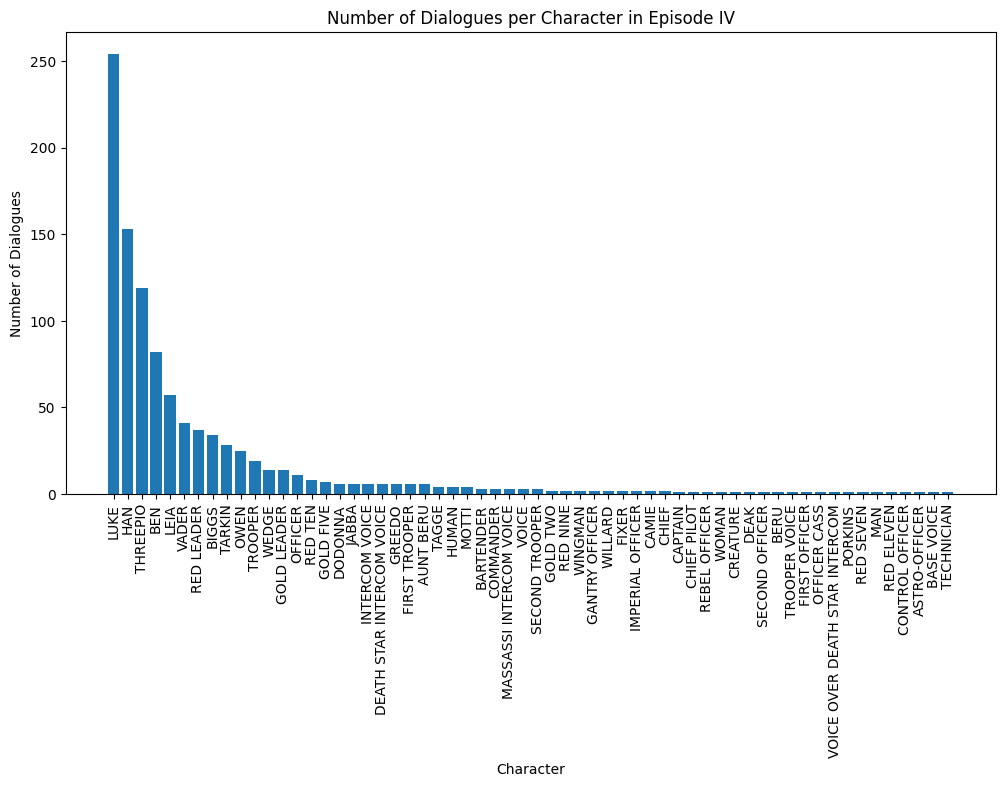

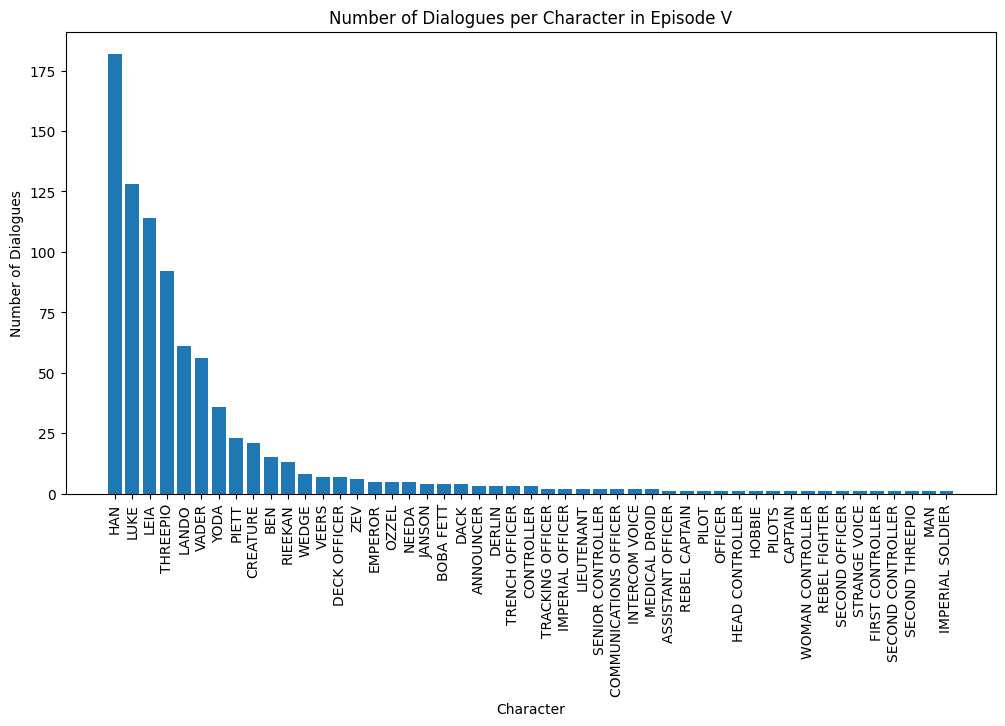

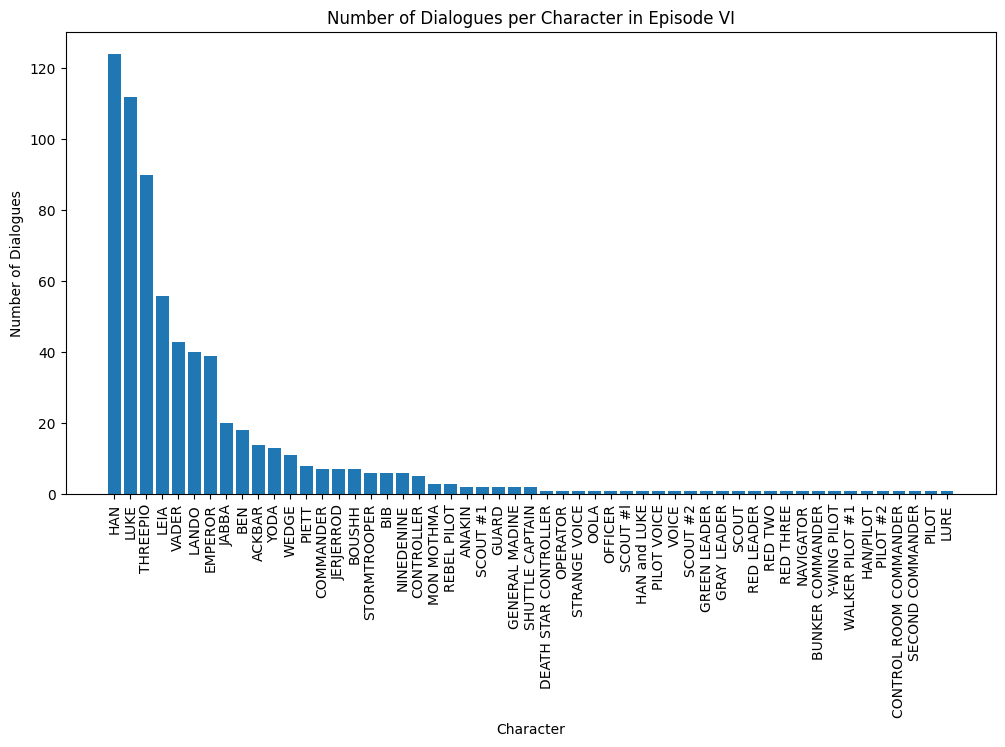

In [ ]:
def plot_dialogue_counts(df, episode):
    # Count the number of dialogues per character (i.e., frequency of each character)
    counts = df['character'].value_counts()
    
    # Create a new figure with specified width and height
    plt.figure(figsize=(12, 6))
    
    # Plot a bar chart with character names on the x-axis and dialogue counts on the y-axis
    plt.bar(counts.index, counts.values)
    
    # Set the title of the plot with the episode number
    plt.title(f'Number of Dialogues per Character in Episode {episode}')
    
    # Label the x-axis as "Character"
    plt.xlabel('Character')
    
    # Label the y-axis as "Number of Dialogues"
    plt.ylabel('Number of Dialogues')
    
    # Rotate x-axis labels vertically for better readability
    plt.xticks(rotation=90)
    
    # Display the plot
    plt.show()


In [21]:
# Combine the individual episode DataFrames into one full DataFrame
all_episodes_df = pd.concat([episode_iv_df, episode_v_df, episode_vi_df])
# Get a list of all unique character names across all episodes
all_episodes_df['character'].unique()


array(['THREEPIO', 'LUKE', 'IMPERIAL OFFICER', 'VADER', 'REBEL OFFICER',
       'TROOPER', 'CHIEF PILOT', 'CAPTAIN', 'WOMAN', 'FIXER', 'CAMIE',
       'BIGGS', 'DEAK', 'LEIA', 'COMMANDER', 'SECOND OFFICER',
       'FIRST TROOPER', 'SECOND TROOPER', 'BERU', 'OWEN', 'AUNT BERU',
       'BEN', 'TAGGE', 'MOTTI', 'TARKIN', 'BARTENDER', 'CREATURE',
       'HUMAN', 'HAN', 'GREEDO', 'JABBA', 'OFFICER CASS',
       'VOICE OVER DEATH STAR INTERCOM', 'OFFICER', 'VOICE',
       'GANTRY OFFICER', 'INTERCOM VOICE', 'TROOPER VOICE',
       'FIRST OFFICER', 'WILLARD', 'DEATH STAR INTERCOM VOICE', 'DODONNA',
       'GOLD LEADER', 'WEDGE', 'MAN', 'RED LEADER', 'CHIEF',
       'MASSASSI INTERCOM VOICE', 'RED TEN', 'RED SEVEN', 'PORKINS',
       'RED NINE', 'RED ELEVEN', 'ASTRO-OFFICER', 'CONTROL OFFICER',
       'GOLD FIVE', 'GOLD TWO', 'WINGMAN', 'BASE VOICE', 'TECHNICIAN',
       'RIEEKAN', 'DECK OFFICER', 'ASSISTANT OFFICER', 'LIEUTENANT',
       'DERLIN', 'ZEV', 'ANNOUNCER', 'SENIOR CONTROLLER', 'PIE

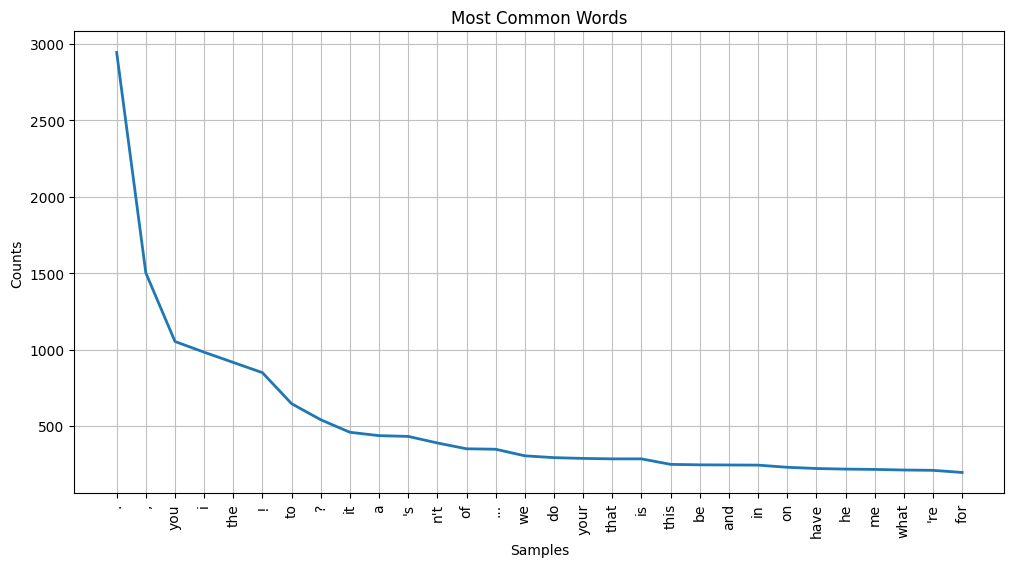

In [23]:
# Combine all dialogue text from all episodes into one long string
full_text = ' '.join(all_episodes_df['dialogue'])
# Convert the text to lowercase and tokenize it into individual words
tokens = word_tokenize(full_text.lower())
# Create a frequency distribution of all tokens
fdist_raw = FreqDist(tokens)
# Plot the 30 most common words from the raw, unprocessed script
plt.figure(figsize=(12, 6))
fdist_raw.plot(30, title='Most Common Words')
plt.show()


In [24]:
# Get the list of common English stopwords from NLTK (e.g., "the", "is", "and")
stop_words = set(stopwords.words('english'))
# Create a lemmatizer to reduce words to their root form (e.g., "running" → "run")
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    # Convert text to lowercase and tokenize it into words
    tokens = word_tokenize(text.lower())
    
    # Keep only alphabetic words and remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    
    # Lemmatize each remaining token
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return tokens
# Apply the cleaning function to every dialogue line in the dataset
# Result: a new column "new_script" with the cleaned list of words
all_episodes_df['new_script'] = all_episodes_df['dialogue'].apply(clean_text)
# Show the first few rows of the updated DataFrame
all_episodes_df.head()
all_episodes_df['new_script_str'] = all_episodes_df['new_script'].apply(lambda x: " ".join(x))


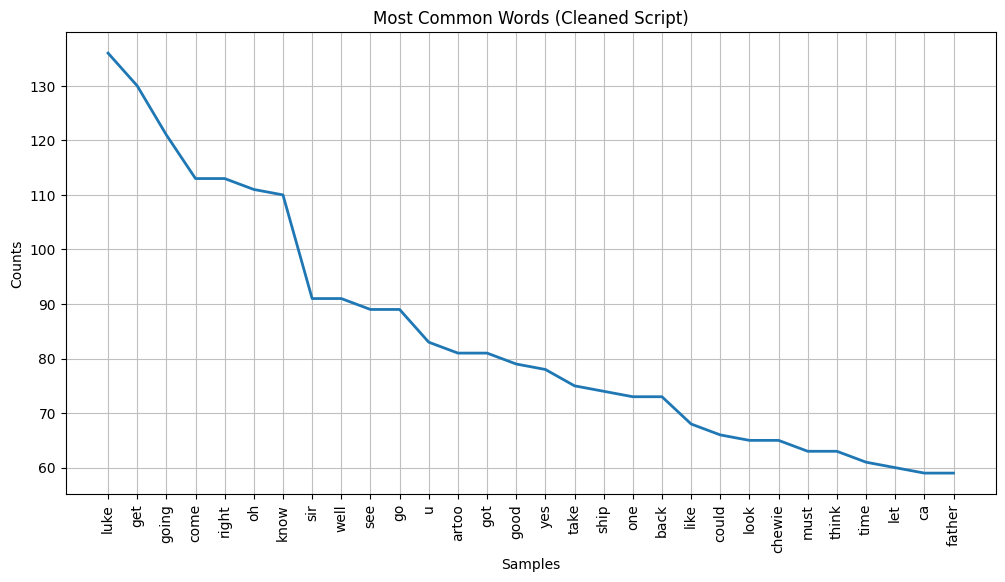

In [10]:
all_words = [word for sublist in all_episodes_df['new_script'] for word in sublist]
fdist_clean = FreqDist(all_words)

plt.figure(figsize=(12, 6))
fdist_clean.plot(30, title='Most Common Words (Cleaned Script)')
plt.show()

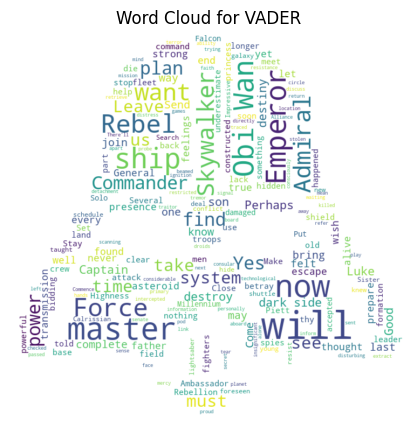

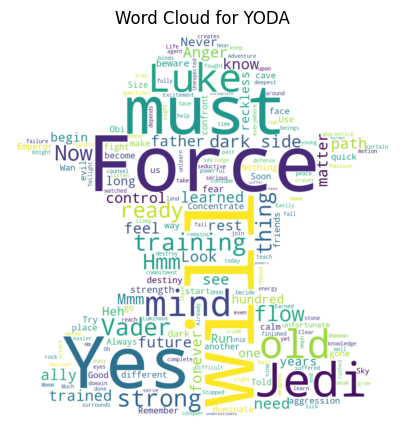

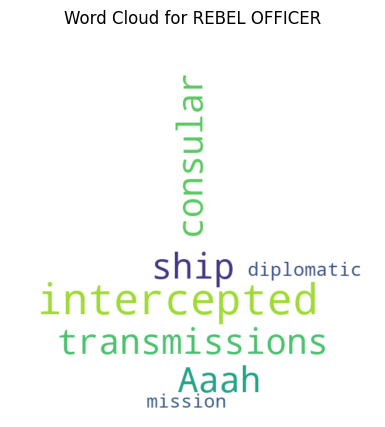

In [25]:
#function definition
def generate_wordcloud(character, mask_path, color='white'):
        # Filter dialogues for the specified character and join into one string
    text = ' '.join(all_episodes_df[all_episodes_df['character'] == character]['dialogue'])
    # Load the mask image (shape of the word cloud)
    mask = np.array(Image.open(mask_path))
    # Generate the word cloud using the character's dialogue and the provided mask
    wordcloud = WordCloud(width=800, height=400, background_color=color, mask=mask).generate(text)
    # Set the figure size for display
    plt.figure(figsize=(10, 5))
    # Display the word cloud image
    plt.imshow(wordcloud, interpolation='bilinear')
    # Hide axes (clean look)
    plt.axis('off')
    # Add a title to the plot
    plt.title(f'Word Cloud for {character}')
    # Show the plot
    plt.show()
#Function calling
generate_wordcloud('VADER', 'C:/BI/star_wars_movies_scripts/vader.jpg')
generate_wordcloud('YODA', 'C:/BI/star_wars_movies_scripts/yoda.png')
generate_wordcloud('REBEL OFFICER', 'C:/BI/star_wars_movies_scripts/rebel alliance.png')






In [26]:
# Initialize a TF-IDF Vectorizer that automatically removes English stopwords
tfidf = TfidfVectorizer(stop_words='english')
# Fit the TF-IDF model and transform the dialogue column into a TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(all_episodes_df['dialogue'])
# Get the list of all token (word) names in the matrix
feature_names = tfidf.get_feature_names_out()
# Convert the sparse matrix to a dense matrix (full numeric values)
dense = tfidf_matrix.todense()
# Convert the dense matrix to a list of lists
denselist = dense.tolist()
# Create a DataFrame from the dense matrix with words as columns
tfidf_df = pd.DataFrame(denselist, columns=feature_names)
# Sum TF-IDF scores across all rows (dialogues) for each word, sort, and get the top 20
top_words = tfidf_df.sum().sort_values(ascending=False).head(20)
# Print the top 20 most relevant words based on TF-IDF
print("Top 20 Relevant Words (TF-IDF):\n", top_words)
tfidf_matrix = tfidf.fit_transform(all_episodes_df['new_script_str'])


Top 20 Relevant Words (TF-IDF):
 don       50.426640
luke      48.363471
ll        46.623636
right     46.415782
come      45.704152
going     44.468674
oh        41.768271
yes       40.063396
know      35.938680
sir       34.640962
artoo     33.645167
chewie    30.195207
ve        28.785320
good      27.361049
got       26.613497
let       25.780021
just      24.780187
think     22.474341
look      22.452864
help      21.772389
dtype: float64


In [27]:
# Create an instance of the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()
def analyze_sentiment(text):
    # Analyze the sentiment of a given text and return only the 'compound' score
    return analyzer.polarity_scores(text)['compound']
# Apply the sentiment function to every dialogue line and store results in a new column
all_episodes_df['sentiment'] = all_episodes_df['dialogue'].apply(analyze_sentiment)
# Filter rows where the character is part of the Light Side
light_side = all_episodes_df[all_episodes_df['character'].isin(['LUKE', 'YODA', 'LEIA'])]

# Filter rows where the character is part of the Dark Side
dark_side = all_episodes_df[all_episodes_df['character'].isin(['VADER', 'EMPEROR', 'PALPATINE'])]
# Calculate and print the average sentiment for Light Side characters
print("Light Side average sentiment:", light_side['sentiment'].mean())

# Calculate and print the average sentiment for Dark Side characters
print("Dark Side average sentiment:", dark_side['sentiment'].mean())


Light Side average sentiment: 0.050832077922077924
Dark Side average sentiment: 0.050775543478260875


Despite thematic differences in alignment,the language used by characters in Star Wars is often measured and emotionally neutral, which reflects in the very similar sentiment scores.



C:\Users\rande\AppData\Local\Temp\ipykernel_18564\3989815021.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Side')


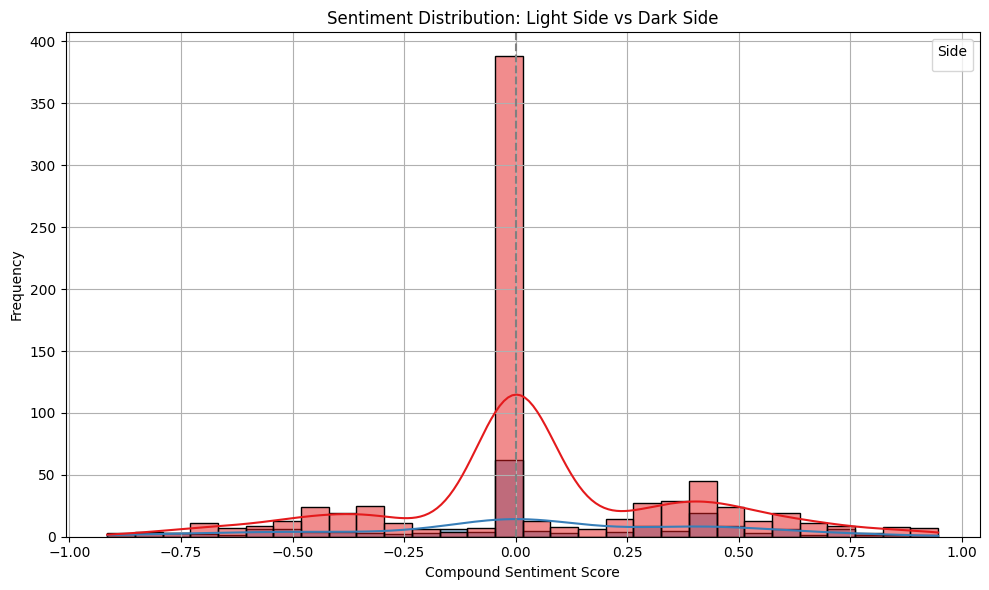

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create a new column for "side" (Light or Dark)
all_episodes_df['side'] = all_episodes_df['character'].apply(
    lambda x: 'Light Side' if x in ['LUKE', 'YODA', 'LEIA']
    else 'Dark Side' if x in ['VADER', 'EMPEROR', 'PALPATINE']
    else 'Other'
)

# Filter only Light and Dark Side
sides_df = all_episodes_df[all_episodes_df['side'].isin(['Light Side', 'Dark Side'])]

# Plot sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=sides_df, x='sentiment', hue='side', kde=True, bins=30, palette='Set1')
plt.title('Sentiment Distribution: Light Side vs Dark Side')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.axvline(0, color='gray', linestyle='--')  # Neutral line
plt.legend(title='Side')
plt.grid(True)
plt.tight_layout()
plt.show()

Whether Light Side characters tend to speak more positively than Dark Side.Whether either side uses more neutral or extreme language.
Overlapping areas show similarity in tone.